In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [26]:
dataset1 = pd.read_csv('/content/drive/MyDrive/DEEPLEARNING/DEEP 1 - Sheet1.csv')
X = dataset1[['input']].values
y = dataset1[['output']].values
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]]
[[25]
 [12]
 [30]
 [15]
 [17]
 [ 3]
 [ 5]
 [21]
 [14]
 [19]
 [18]
 [ 6]
 [ 7]
 [ 2]
 [ 1]]


In [27]:
dataset1.head(5)

,input,output
0,1,25
1,2,12
2,3,30
3,4,15
4,5,17


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [29]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [31]:
# Name:Mukesh B
# Register Number:212223230128
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        # Include your code here
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}

  def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x

In [32]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop(lig.parameters(),lr=0.001)

In [33]:
# Name: Mukesh B
# Register Number: 212223230128
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs):
      optimizer.zero_grad()
      loss=criterion(ai_brain(X_train),y_train)
      loss.backward()
      optimizer.step()
      lig.history['loss'].append(loss.item())
      if epoch % 200 == 0:
        print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [34]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 255.258743
Epoch [200/2000], Loss: 150.923477
Epoch [400/2000], Loss: 83.137917
Epoch [600/2000], Loss: 71.018188
Epoch [800/2000], Loss: 64.147537
Epoch [1000/2000], Loss: 58.194893
Epoch [1200/2000], Loss: 52.995338
Epoch [1400/2000], Loss: 51.041199
Epoch [1600/2000], Loss: 50.958641
Epoch [1800/2000], Loss: 50.916100


In [36]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')

Test Loss: 41.245525


In [38]:
loss_df = pd.DataFrame(lig.history)

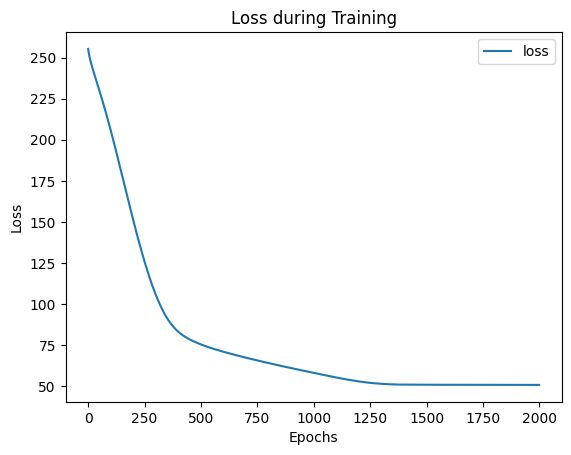

In [39]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [41]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 12.279570579528809
